# Generating Power Spectra for the H5 Cube

## Imports and Extraction

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import sys

In [2]:
sys.path.append("/home/ohrf/Desktop/Curtin/phd-programs/")
from oskareor.reformatter import SimulationReformatter as simref

In [3]:
file = "/home/ohrf/oskareor.data/simulations/project1/fiducial_lightcone_simulation.h5"

data, z_ref, v, voxels, cosmology = simref.extract_h5_data(file)

print(data.shape)
print(v)

H5 data is a lightcone box.
(512, 512, 1024)
[1.         1.         1.99804688]


## Chop up the cube

Divide the cube into 31 chunks, where each chunk's centre occurs at channel $(32*n)+32$ (assuming numbering starts at zero), with a bandwidth spanning across 32 channels. This creates 31 chunks of uniform size which overlap with each other, the end point of one channel being the centre of the next.

In [4]:
# Print channel centres, widths, and start/end points and append to an accumulator list

def chunk_array(data, n_chunks = 32, show_chunks = False):
    """Split a large 3-dimensional datacube into a series of overlapping, evenly distributed, and fixed-size chunks for analysis in a power spectra.

    :param data: The 3-dimensional array to divide into chunks.
    :param n_chunks: The number of chunks to split the data in.
    :param show_chunks: Whether to show the chunk boundaries, defaults to False
    
    :return (chunks, voxels): Two 4-dimensional arrays containing each 3-dimensional chunk, one containing temperature values in Kelvin and the other voxel dimensions in cMpc.
    """
    
    print("Dividing array into chunks ...")

    b = 2 * int(data.shape[2]/n_chunks) # Chunk size

    chunk_values = []
    chunk_voxels = []

    if show_chunks:
        print("Chunk data:")
        print("+"+"—"*61+"+")
        print("| Chunk No.        Range ([start, end])    Centre      Length |")
        print("+"+"—"*61+"+")

    for k in range(n_chunks-1):
        c = int(b/2 * (k + 1))
        i = int(c - b/2)
        f = int(c + b/2)
    
        if show_chunks:
            print(
                f"| {k}" +
                " "*(4-len(str(k))) +
                " "*19 +
                f"[{i: 5d}, {f: 5d}]"+
                " "*5+
                f"{c: 5d}" +
                " "*9 +
                f"{b:3d} |"
            )
    
        chunk_values.append(data[:,:,i:f])
        chunk_voxels.append(voxels[:,:,i:f])
    
    chunk_values = np.array(chunk_values)
    chunk_voxels = np.array(chunk_voxels)
    
    if show_chunks:
        print("+"+"—"*61+"+")

    print(f"Final post-chunk shape: {chunk_values.shape}")
    
    return chunk_values, chunk_voxels
    
chunk_values, chunk_voxels = chunk_array(data = data, show_chunks = True)



Dividing array into chunks ...
Chunk data:
+—————————————————————————————————————————————————————————————+
| Chunk No.        Range ([start, end])    Centre      Length |
+—————————————————————————————————————————————————————————————+
| 0                      [    0,    64]        32          64 |
| 1                      [   32,    96]        64          64 |
| 2                      [   64,   128]        96          64 |
| 3                      [   96,   160]       128          64 |
| 4                      [  128,   192]       160          64 |
| 5                      [  160,   224]       192          64 |
| 6                      [  192,   256]       224          64 |
| 7                      [  224,   288]       256          64 |
| 8                      [  256,   320]       288          64 |
| 9                      [  288,   352]       320          64 |
| 10                     [  320,   384]       352          64 |
| 11                     [  352,   416]       384          64

## Calculate the cylindrical Fourier transform

Next is to calculate the Cylindrical Fourier Transform (CFT or CDFFT). This involves taking a standard 3D FFT and then condensing two of the dimensions into one using Pythagoras' theorem and collecting data in the form of a histogram.

The frequency domain is additionally tapered using the Blackman-Harris window.

In [14]:
# Calculate it for the first chunk
chunk_sel = 5
chunk = chunk_values[chunk_sel, :, :, :]
cvox = chunk_voxels[chunk_sel, :, :, :]

def cylindrical_power_spectrum(data, voxels, bins):
    """Calculate the cylindrical power spectra for a given volume of data.

    :param data: A 3-dimensional array of brightness temperature values in Kelvin.
    :param voxels: A 4-dimensional array of individual voxel dimensions in cMpc.
    :param bins: The number of k_perp and k_para bins as a tuple.
    """
    
    def blackman_harris_window(n, N):
        """Three-term Blackman-Harris Windowing function."""
        a0 = 0.4243801
        a1 = 0.4973406
        a2 = 0.0782793
        
        return a0 - a1 * np.cos(2*np.pi*n/N) + a2 * np.cos(4*np.pi*n/N)
    
    # apply the Blackman-Harris window in the frequency domain
    tdat = np.copy(data)
    for i in range(data.shape[2]):
        # Add half to centre the window
        tdat[:, :, i] = blackman_harris_window(n=i+0.5, N=data.shape[2]) * data[:, :, i]
    
    # Calculate fractional pertubation
    fperb = (data - data.mean()) / data.mean() # Dividing by mean keeps data unitless
    
    # Calculate the total volume and voxel volume
    vol_vox = np.prod(voxels, axis=-1)
    
    # Fourier transform the pertubation on all dimensions
    ftdata = np.fft.fftn(fperb) * vol_vox # Multiplying by voxel volume keeps data unitless
    
    # Take the square magnitude to remove complex values
    power = np.abs(ftdata) ** 2
    
    # Get the k values along each of the three axes, and collapse to cylindrical
    ki = [
        2 * np.pi * np.fft.fftfreq(nx, d=vx)
        for nx, vx in zip(data.shape, voxels.shape)
    ]
    kx, ky, kz = np.meshgrid(*ki, indexing='ij')
    k_perp = np.hypot(kx, ky)
    k_para = np.abs(kz) # Remove negative values from kz

    # Logarithmic k bins
    def log_edges(k, n_bins):
        k_nonzero = k[k > 0]
        return np.logspace(np.log10(np.min(k_nonzero)), np.log10(np.max(k_nonzero)), n_bins)

    k_perp_bins = log_edges(k_perp, bins[0])
    k_para_bins = log_edges(k_para, bins[1])

    # Collapse the power spectrum data into a 2D array
    power_agg, k_perp_edges, k_para_edges = np.histogram2d(
        k_perp.ravel(),
        k_para.ravel(),
        bins=(k_perp_bins, k_para_bins),
        weights=power.ravel(),
    )
    
    # Get the number of modes used to aggregate in a specific bin
    modal_agg, _, _ = np.histogram2d(
        k_perp.ravel(),
        k_para.ravel(),
        bins=(k_perp_bins, k_para_bins),
    )
    
    power_2d = np.divide(power_agg, modal_agg)
    
    return power_2d, modal_agg, k_perp_edges, k_para_edges

bins = np.array([64, 64], dtype="int")

    
ps2d, n_kv, k_perp, k_para = cylindrical_power_spectrum(chunk, cvox, bins=bins)

/tmp/ipykernel_13152/572846433.py:72: RuntimeWarning: invalid value encountered in divide
  power_2d = np.divide(power_agg, modal_agg)


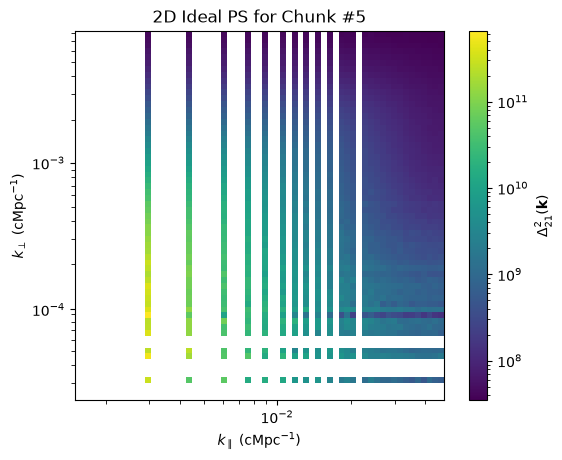

In [15]:
fig, ax = plt.subplots()
img = ax.imshow(ps2d, cmap="viridis", norm="log", origin="lower")

cb = fig.colorbar(img, ax=ax, label=r"$\Delta^2_{21}\left(\mathbf{k}\right)$")

ax.set_xlabel(r"$k_{\parallel}$ ($\mathrm{cMpc}^{-1}$)")
ax.set_ylabel(r"$k_{\perp}$ ($\mathrm{cMpc}^{-1}$)")

# Whole power ticks
def whole_power_ticks(edges):
    log_edges = np.log10(edges)
    exp = np.arange(np.ceil(log_edges.min()), np.floor(log_edges.max()) + 1).astype(int)
    idx = [int(np.argmin(np.abs(log_edges - e))) for e in exp]
    labels = [f"$10^{{{e}}}$" for e in exp]
    return idx, labels

# Unlabelled minor ticks
def minor_power_ticks(edges):
    log_edges = np.log10(edges)
    minip = np.arange(np.floor(log_edges.min()), np.ceil(log_edges.max()) + 1).astype(int)
    minor_log = [np.log10(m * 10.0 ** d) for d in minip for m in range(2, 10)]
    minor_log = [l for l in minor_log if log_edges.min() <= l <= log_edges.max()]
    return np.interp(minor_log, log_edges, np.arange(len(edges)))

xtick_idx, xtick_labels = whole_power_ticks(k_para)
ytick_idx, ytick_labels = whole_power_ticks(k_perp)

ax.set_xticks(xtick_idx)
ax.set_xticklabels(xtick_labels)
ax.set_xticks(minor_power_ticks(k_para), minor=True)

ax.set_yticks(ytick_idx)
ax.set_yticklabels(ytick_labels)
ax.set_yticks(minor_power_ticks(k_perp), minor=True)

ax.tick_params(which="minor", length=3)

ax.set_title(f"2D Ideal PS for Chunk #{chunk_sel}")

plt.show()